# ISCAS/TCAS2 2026


In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass

np.set_printoptions(precision=4, suppress=True)

SEED = 2026
rng = np.random.default_rng(SEED)

In [3]:
@dataclass
class Params:
    n: int = 8
    T_max: int = 48
    S_max: int = 8
    c_grover: float = 1.0
    shots: int = 4096

params = Params()
N = 2 ** params.n
T_values = np.arange(0, params.T_max + 1)
S_values = np.arange(0, params.S_max + 1)
#print("N =", N)
#print("T range =", (T_values.min(), T_values.max()))
#print("S range =", (S_values.min(), S_values.max()))

## Utilities

We use two different objects:

- the **exact ideal Grover success probability** for one marked item,

  $$
  P_{\mathrm{Grover}}(T)
  =
  \sin^2((2T+1)\theta),
  \qquad
  \theta=\arcsin(1/\sqrt{N});
  $$

- the **quadratic Grover envelope** used in the additive bound,

  $$
  P_T(T)
  \approx
  kT^2 2^{-n}.
  $$

The additive model is then

$$
P_{\mathrm{add}}(T,S)
=
\min\left\{1,\frac{2^S+kT^2}{2^n}\right\}.
$$

This is a resource-scaling model, not a claim that every circuit trajectory exactly follows a monotone curve. Exact Grover dynamics still oscillates.


In [4]:
def grover_exact_success(T, n):
    """Exact ideal Grover success probability for one marked item among N=2^n."""
    N = 2 ** n
    theta = math.asin(1 / math.sqrt(N))
    T = np.asarray(T, dtype=float)
    return np.sin((2 * T + 1) * theta) ** 2


def grover_envelope(T, n, c=1.0):
    """Quadratic query contribution used as a rank-budget/envelope model."""
    N = 2 ** n
    T = np.asarray(T, dtype=float)
    return np.minimum(1.0, c * T**2 / N)


def advice_contribution(S, n):
    """Advice/side-information contribution 2^S / 2^n."""
    N = 2 ** n
    S = np.asarray(S, dtype=float)
    return np.minimum(1.0, 2**S / N)


def additive_success(T, S, n, c=1.0):
    """Additive upper/envelope model: (2^S + c T^2) / 2^n."""
    N = 2 ** n
    T = np.asarray(T, dtype=float)
    S = np.asarray(S, dtype=float)
    return np.minimum(1.0, (2**S + c * T**2) / N)


def multiplicative_proxy(T, S, n, c=1.0):
    """Simple multiplicative proxy used only for visual comparison.

    This is not the theorem; it is a deliberately simple comparator showing
    what a product-like composition of query and advice terms would look like.
    """
    N = 2 ** n
    T = np.asarray(T, dtype=float)
    S = np.asarray(S, dtype=float)
    return np.minimum(1.0, c * (T**2) * (2**S) / N)


def binomial_observations(p, shots, rng):
    """Simulate finite-shot observations of probabilities."""
    p = np.clip(np.asarray(p, dtype=float), 0.0, 1.0)
    return rng.binomial(shots, p) / shots


## Experiment A: Grover baseline versus quadratic envelope

This experiment fixes the query-only part of the story. For small $T$, ideal Grover grows approximately as

$$
P_{\mathrm{Grover}}(T)\approx (2T+1)^2 2^{-n},
$$

before the first maximum and subsequent oscillations. The additive bound uses the corresponding $T^2$ scaling as the query contribution.


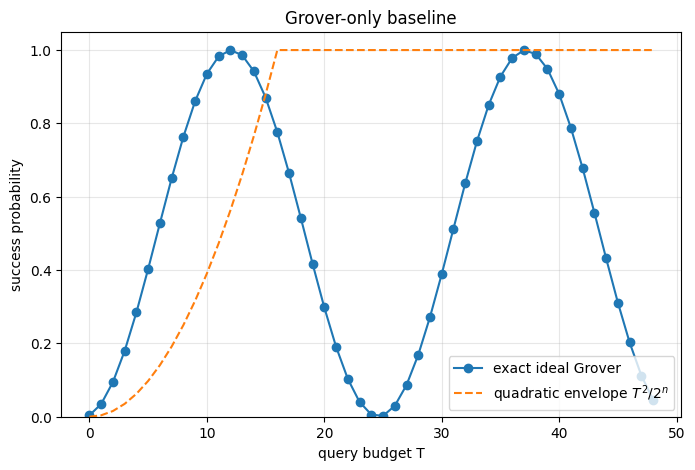

First sampled maximum at T = 12, P = 0.9999


In [5]:
P_exact = grover_exact_success(T_values, params.n)
P_env = grover_envelope(T_values, params.n, c=params.c_grover)

plt.figure(figsize=(8, 5))
plt.plot(T_values, P_exact, marker="o", label="exact ideal Grover")
plt.plot(T_values, P_env, linestyle="--", label=r"quadratic envelope $T^2/2^n$")
plt.xlabel("query budget T")
plt.ylabel("success probability")
plt.title("Grover-only baseline")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

peak_T = int(T_values[np.argmax(P_exact)])
print(f"First sampled maximum at T = {peak_T}, P = {P_exact.max():.4f}")


The exact Grover curve is oscillatory, while the theorem uses the early-time/rank-budget scaling $T^2$. This is why the additive bound should be interpreted as a resource envelope rather than as a pointwise prediction of the full Grover trajectory.

In cryptanalytic terms, the Grover-only baseline represents an ideal exhaustive key-search attack against a black-box encryption oracle. The marked state corresponds to the secret key, and the quadratic growth $T^2 2^{-n}$ captures the query-only contribution to the inversion probability. This curve therefore provides the isolated reference term that, in the non-isolated model, is combined additively with the side-information contribution $2^S2^{-n}$.

## Experiment B: Additive success landscape $P(T,S)$

The core visualization is the additive landscape

$$
P_{\mathrm{add}}(T,S)
=
\min\left\{1,\frac{2^S+T^2}{2^n}\right\}.
$$

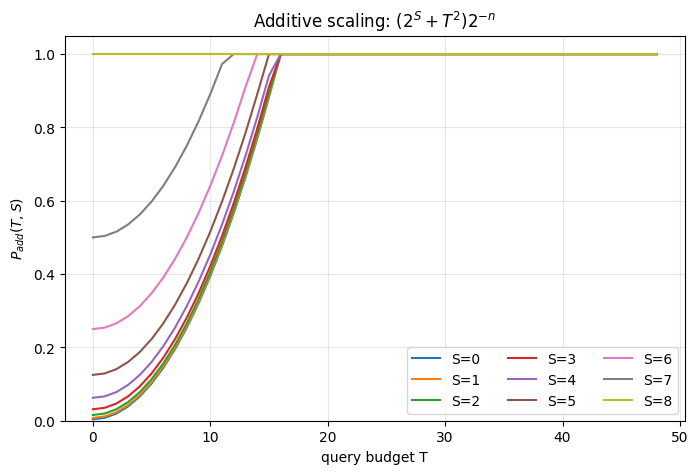

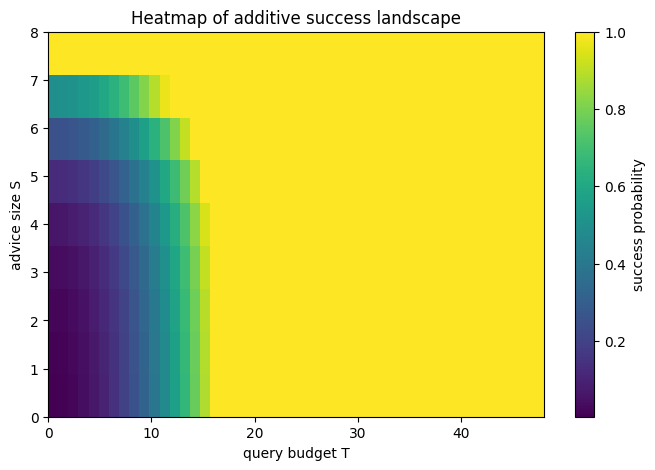

In [13]:
TT, SS = np.meshgrid(T_values, S_values, indexing="xy")
P_add = additive_success(TT, SS, params.n, params.c_grover)
P_mult = multiplicative_proxy(TT, SS, params.n, params.c_grover)

plt.figure(figsize=(8, 5))
for S in [0, 1, 2, 3, 4, 5, 6, 7, 8]:
    plt.plot(T_values, additive_success(T_values, S, params.n), label=f"S={S}")
plt.xlabel("query budget T")
plt.ylabel(r"$P_{add}(T,S)$")
plt.title(r"Additive scaling: $(2^S+T^2)2^{-n}$")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend(ncol=3)
plt.show()

plt.figure(figsize=(8, 5))
im = plt.imshow(P_add, origin="lower", aspect="auto",
                extent=[T_values.min(), T_values.max(), S_values.min(), S_values.max()])
plt.colorbar(im, label="success probability")
plt.xlabel("query budget T")
plt.ylabel("advice size S")
plt.title(r"Heatmap of additive success landscape")
plt.show()


These plots visualize the resource geometry predicted by the non-isolated-channel model. The Grover query contribution grows as $T^2 2^{-n}$, while the quantum side-information contribution grows as $2^S2^{-n}$. Their sum produces an additive success landscape, showing that increasing $S$ shifts the success curve upward even before additional oracle queries are applied.




## Experiment C: Isoprobability curves

A very clear way to display the additive bound is to solve for the minimal number of queries needed to reach a fixed target success probability $p$.

Starting from

$$
p \approx \frac{2^S+T^2}{2^n},
$$

we obtain

$$
T_{\min}(p,S)
\approx
\sqrt{p2^n-2^S}.
$$

When $2^S$ becomes comparable to $p2^n$, the query budget drops sharply. This is the visual footprint of the additive side-information contribution.


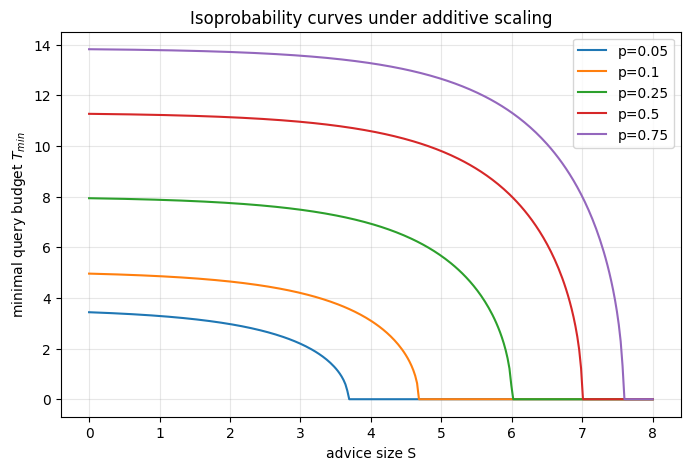

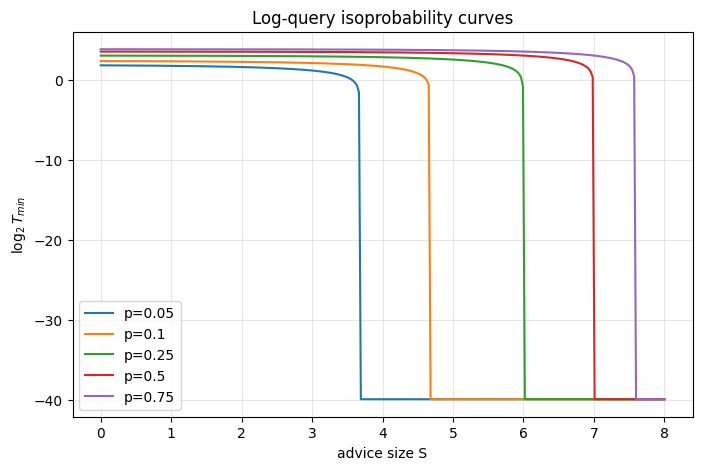

In [7]:
def Tmin_additive(p, S, n, c=1.0):
    N = 2 ** n
    S = np.asarray(S, dtype=float)
    residual = np.maximum(0.0, p * N - 2**S)
    return np.sqrt(residual / c)

p_targets = [0.05, 0.10, 0.25, 0.50, 0.75]
S_dense = np.linspace(0, params.S_max, 300)

plt.figure(figsize=(8, 5))
for p in p_targets:
    plt.plot(S_dense, Tmin_additive(p, S_dense, params.n), label=f"p={p}")
plt.xlabel("advice size S")
plt.ylabel(r"minimal query budget $T_{min}$")
plt.title("Isoprobability curves under additive scaling")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
for p in p_targets:
    T_min = Tmin_additive(p, S_dense, params.n)
    log_T = np.log2(np.maximum(T_min, 1e-12))
    plt.plot(S_dense, log_T, label=f"p={p}")
plt.xlabel("advice size S")
plt.ylabel(r"$\log_2 T_{min}$")
plt.title("Log-query isoprobability curves")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


The steep decrease of $T_{\min}$ as $S$ approaches the threshold

$$
2^S \approx p2^n
$$
The advice term does not merely rescale the Grover query budget; it can directly cover part of the successful subspace.

For a fixed target success probability $p$, the additive model yields
$$
T_{\min}(p,S)=\max\left\{0,\sqrt{p2^n-2^S}\right\}.
$$
The resulting isoprobability curves show that quantum side information reduces the remaining Grover query budget by contributing directly to the success probability. Once $2^S \ge p2^n$, the advice contribution alone reaches the target threshold and no additional oracle queries are required. This behavior differs from a multiplicative time-space geometry, where $\log_2 T_{\min}$ would decrease approximately linearly with $S$.


## Experiment D: Advice-only, Grover-only and mixed/additive strategy

This experiment mirrors the proof intuition. We compare:

$$
\delta_T = kT^2 2^{-n},
$$

$$
\delta_S = 2^S2^{-n},
$$

and

$$
\delta_{\mathrm{add}} \leq \delta_T + \delta_S.
$$

A finite-shot version is added only to show what the curves would look like under measurement statistics.


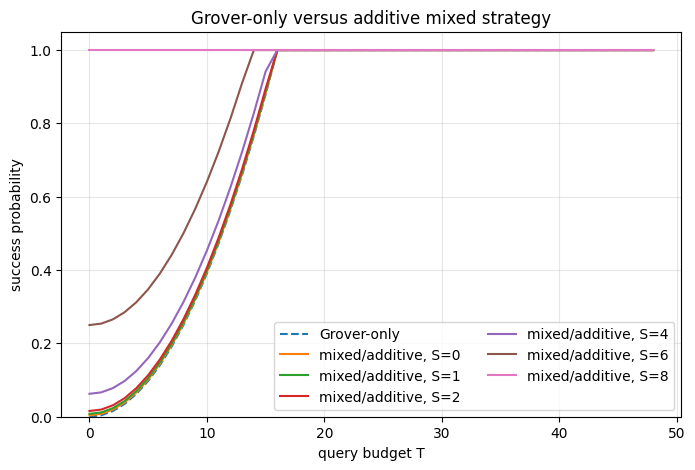

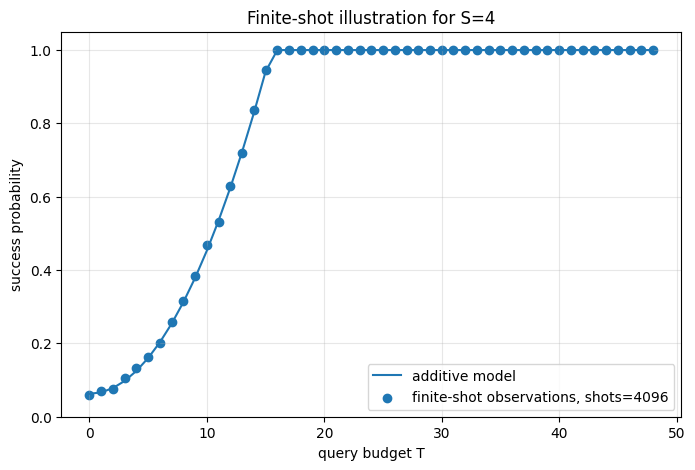

In [8]:
selected_S = [0, 1, 2, 4, 6, 8]

plt.figure(figsize=(8, 5))
plt.plot(T_values, grover_envelope(T_values, params.n), linestyle="--", label="Grover-only")
for S in selected_S:
    plt.plot(T_values, additive_success(T_values, S, params.n), label=f"mixed/additive, S={S}")
plt.xlabel("query budget T")
plt.ylabel("success probability")
plt.title("Grover-only versus additive mixed strategy")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.show()

# Finite-shot illustration for one value of S
S_demo = 4
p_true = additive_success(T_values, S_demo, params.n)
p_obs = binomial_observations(p_true, params.shots, rng)

plt.figure(figsize=(8, 5))
plt.plot(T_values, p_true, label="additive model")
plt.scatter(T_values, p_obs, label=f"finite-shot observations, shots={params.shots}")
plt.xlabel("query budget T")
plt.ylabel("success probability")
plt.title(f"Finite-shot illustration for S={S_demo}")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


The additive curve can be read as the union of two mechanisms: direct side information and Grover-type query amplification. The experiment does not claim that these mechanisms are independent; the theorem only needs the rank/additive upper structure.

For $S=4$, the additive model predicts
$$
P_{\mathrm{add}}(T,4)=\min\left\{1,\frac{16+T^2}{2^n}\right\}.
$$
The finite-shot observations show that the additive success law remains statistically visible under a realistic sampling budget. The initial offset at $T=0$ is the advice-only contribution, while the quadratic growth in $T$ is the Grover query contribution.

## Experiment F: Rank-budget Monte Carlo

The proof of the additive bound can be visualized through subspace ranks.

Let:

$$
\operatorname{rank}(\Pi_S)\leq 2^S,
$$

and

$$
\operatorname{rank}(\Pi_T)\leq cT^2.
$$

Then the useful or lucky subspace satisfies

$$
\operatorname{rank}(\Pi)\leq 2^S+cT^2.
$$

In this toy Monte Carlo experiment, the marked key is uniformly random and success occurs if it lies in the union of an advice-accessible set and a query-accessible set.

To make the rank-budget argument explicit, we model the advice contribution and the Grover-query contribution as two accessible subspaces of the $2^n$-dimensional key space. The advice subspace has rank at most $2^S$, while the query-induced subspace has rank at most $cT^2$. The probability that the correct preimage lies in their span is therefore upper bounded by
$$
\frac{\operatorname{rank}(\Pi_S+\Pi_T)}{2^n}
\le
\frac{2^S+cT^2}{2^n}.
$$
The Monte Carlo estimates remain close to, and typically below, this additive upper bound, with deviations explained by finite-sample fluctuations and by overlaps between the advice and query subspaces.

In [10]:
def rank_budget_estimate(T, S, n, c=1.0, trials=5000, rng=None):
    """Fast Bernoulli Monte Carlo for the lucky-subspace interpretation.

    For a uniformly random marked key and two independently selected accessible
    sets of ranks a=2^S and q=cT^2, the membership probability in their union is

        1 - (1-a/N)(1-q/N).

    We sample this Bernoulli probability to mimic finite experimental statistics.
    The additive theorem uses the upper bound (a+q)/N.
    """
    rng = np.random.default_rng() if rng is None else rng
    N = 2 ** n
    advice_rank = min(N, max(0.0, 2 ** S))
    query_rank = min(N, max(0.0, c * T**2))
    p_union = 1.0 - (1.0 - advice_rank / N) * (1.0 - query_rank / N)
    return rng.binomial(trials, np.clip(p_union, 0.0, 1.0)) / trials

# Keep the Monte Carlo grid moderate.
mc_T_values = np.arange(0, 33)
mc_S_values = np.arange(0, 9)
trials = 5000

mc_records = []
for S in mc_S_values:
    for T in mc_T_values:
        est = rank_budget_estimate(T, S, params.n, c=params.c_grover, trials=trials, rng=rng)
        upper = additive_success(T, S, params.n, c=params.c_grover)
        mc_records.append({"T": T, "S": S, "mc_success": est, "additive_upper": upper})

mc_df = pd.DataFrame(mc_records)
mc_df.head()


,T,S,mc_success,additive_upper
0,0,0,0.0050,0.003906
1,1,0,0.0114,0.007812
2,2,0,0.0208,0.019531
3,3,0,0.0396,0.039062
4,4,0,0.0650,0.066406


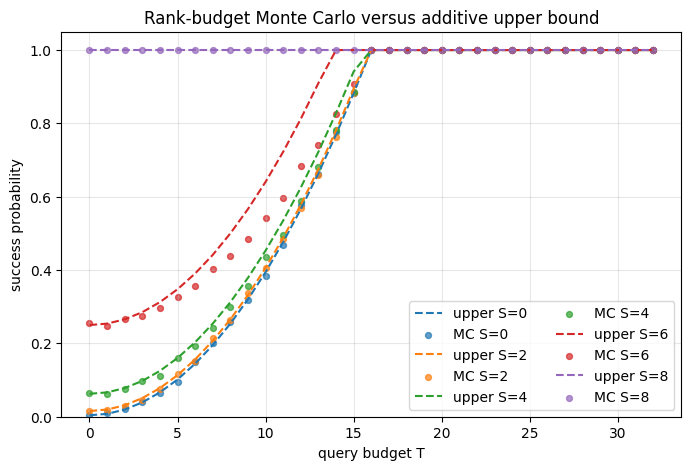

/tmp/ipykernel_3379/2522214732.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_mc = mc_df.groupby("S").apply(


,S,mean_gap_upper_minus_mc,max_mc_success,max_upper
0,0,-0.000314,1.0,1.0
1,1,0.001853,1.0,1.0
2,2,0.001835,1.0,1.0
3,3,0.005592,1.0,1.0
4,4,0.009574,1.0,1.0
5,5,0.018813,1.0,1.0
6,6,0.031940,1.0,1.0
7,7,0.048466,1.0,1.0
8,8,0.000000,1.0,1.0


In [11]:
plt.figure(figsize=(8, 5))
for S in [0, 2, 4, 6, 8]:
    sub = mc_df[mc_df["S"] == S]
    plt.plot(sub["T"], sub["additive_upper"], linestyle="--", label=f"upper S={S}")
    plt.scatter(sub["T"], sub["mc_success"], s=18, alpha=0.7, label=f"MC S={S}")
plt.xlabel("query budget T")
plt.ylabel("success probability")
plt.title("Rank-budget Monte Carlo versus additive upper bound")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.show()

summary_mc = mc_df.groupby("S").apply(
    lambda g: pd.Series({
        "mean_gap_upper_minus_mc": float(np.mean(g["additive_upper"] - g["mc_success"])),
        "max_mc_success": float(g["mc_success"].max()),
        "max_upper": float(g["additive_upper"].max()),
    })
).reset_index()
summary_mc


The Monte Carlo estimates usually lie below the additive rank upper bound. The reason is that two random accessible sets can overlap, whereas the theorem only requires the subadditivity

$$
\operatorname{rank}(A+B)\leq \operatorname{rank}(A)+\operatorname{rank}(B).
$$




## Experiment G: Simple non-isolated channel diagnostic

This final experiment is deliberately small and circuit-inspired.

We simulate a key register of dimension $N=2^{n_{\mathrm{small}}}$ and compare:

1. **isolated Grover**, where the oracle is unitary on the key register;
2. **persistent leakage**, where a channel copies a coarse function $h(x)$ into an environment and the environment is traced out.

Tracing out the environment dephases coherences between different $h(x)$ sectors:

$$
\rho_{xy}\mapsto 0
\quad\text{when}\quad
h(x)\neq h(y).
$$

This is not the additive-bound experiment itself. It is a diagnostic showing how a non-isolated channel can deform the coherent Grover trajectory.


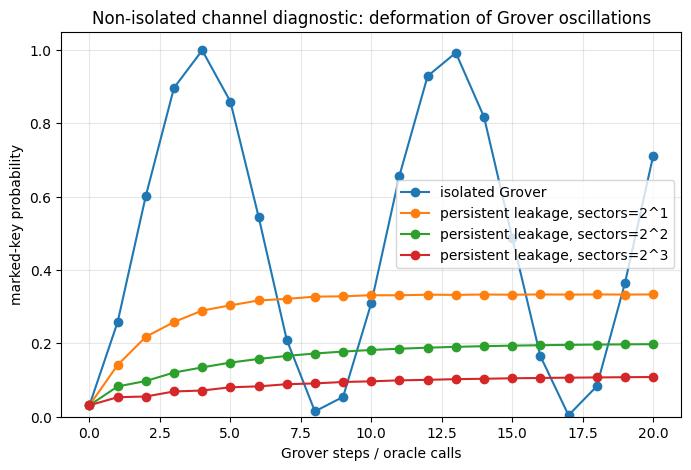

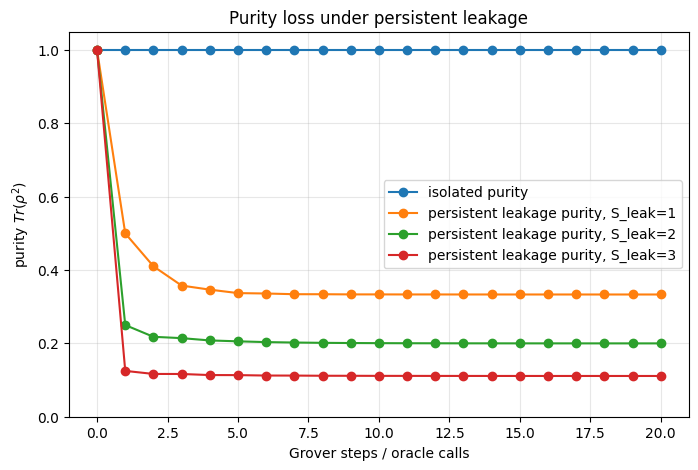

In [12]:
def diffusion_matrix(N):
    s = np.ones((N, 1), dtype=complex) / np.sqrt(N)
    return 2 * (s @ s.conj().T) - np.eye(N, dtype=complex)


def phase_oracle_matrix(N, marked):
    O = np.eye(N, dtype=complex)
    O[marked, marked] = -1
    return O


def dephase_by_labels(rho, labels):
    labels = np.asarray(labels)
    mask = labels[:, None] == labels[None, :]
    return rho * mask


def simulate_leaky_grover(n_small=5, marked=5, S_leak=1, T_max=20, persistent=True):
    """Density-matrix simulation of ideal/echoed versus persistent leakage.

    S_leak controls the number of coarse leakage sectors 2^S_leak.
    For S_leak=0, no dephasing is applied.
    """
    N = 2 ** n_small
    D = diffusion_matrix(N)
    O = phase_oracle_matrix(N, marked)
    psi0 = np.ones((N, 1), dtype=complex) / np.sqrt(N)
    rho = psi0 @ psi0.conj().T

    if S_leak == 0:
        labels = np.zeros(N, dtype=int)
    else:
        # Coarse side-information label. The low S_leak bits define the sector.
        labels = np.arange(N) % (2 ** S_leak)

    probs = [float(np.real(rho[marked, marked]))]
    purities = [float(np.real(np.trace(rho @ rho)))]

    for _ in range(T_max):
        # Phase oracle.
        rho = O @ rho @ O.conj().T
        # Persistent leakage = environment is not uncomputed before being discarded.
        if persistent and S_leak > 0:
            rho = dephase_by_labels(rho, labels)
        # Diffusion on the search register.
        rho = D @ rho @ D.conj().T
        probs.append(float(np.real(rho[marked, marked])))
        purities.append(float(np.real(np.trace(rho @ rho))))
    return np.array(probs), np.array(purities)

n_small = 5
marked = 5
T_small = np.arange(0, 21)

p_iso, purity_iso = simulate_leaky_grover(n_small=n_small, marked=marked, S_leak=0, T_max=T_small.max(), persistent=False)

plt.figure(figsize=(8, 5))
plt.plot(T_small, p_iso, marker="o", label="isolated Grover")
for S_leak in [1, 2, 3]:
    p_leak, _ = simulate_leaky_grover(n_small=n_small, marked=marked, S_leak=S_leak, T_max=T_small.max(), persistent=True)
    plt.plot(T_small, p_leak, marker="o", label=f"persistent leakage, sectors=2^{S_leak}")
plt.xlabel("Grover steps / oracle calls")
plt.ylabel("marked-key probability")
plt.title("Non-isolated channel diagnostic: deformation of Grover oscillations")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(T_small, purity_iso, marker="o", label="isolated purity")
for S_leak in [1, 2, 3]:
    _, purity_leak = simulate_leaky_grover(n_small=n_small, marked=marked, S_leak=S_leak, T_max=T_small.max(), persistent=True)
    plt.plot(T_small, purity_leak, marker="o", label=f"persistent leakage purity, S_leak={S_leak}")
plt.xlabel("Grover steps / oracle calls")
plt.ylabel(r"purity $Tr(\rho^2)$")
plt.title("Purity loss under persistent leakage")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


The non-isolated channel diagnostic shows that persistent leakage does not merely damp the Grover curve as an ordinary implementation error would. Instead, the environment retains partial information about the search register, suppressing coherences between leakage sectors and replacing the ideal Grover oscillation with a lower plateau. This is confirmed by the rapid loss of purity of the reduced search state, while the isolated evolution remains pure. These observations provide a circuit-level explanation of why, in the non-isolated model, side information must be treated as an additional resource rather than as a simple perturbation of the Grover query process.

Persistent leakage turns the isolated Grover rotation into an open-system dynamics. As the environment stores sector information, the reduced search state loses purity and the marked-key probability no longer follows the ideal oscillatory pattern. This supports the interpretation that non-isolation changes the effective query model, providing the circuit-level mechanism behind the additive treatment of side information.
